In [9]:
import torch
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc  # Added for memory cleanup
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py

# --- 1. CONFIGURATION ---
num_tasks = 10
seed = 42
alpha_list = [2.0, 1.5, 1.2, 1.0]
g_list = [0.25, 3.0]
depth = 9
hidden_size = 784
activation_name = "tanh"
optimiser = "sgd"
batch_size = 128
lr = 1e-2
epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. OPTIMIZED DATA LOADING ---
def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead[cite: 7]."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)
    return imgs, lbls

print("Fast-loading MNIST to GPU...")
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())

train_imgs, train_lbls = get_gpu_data(mnist_train)
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels)]
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)))
    return perms

permutations = generate_permutations(num_tasks, seed=seed)

# SPEED OPTIMIZATION: Pre-permute the test set for every task once[cite: 8].
# This removes the pixel-shuffling bottleneck inside the triple-nested loop.
permuted_test_bundles = []
for p in permutations:
    permuted_test_bundles.append(test_imgs_raw[:, p])

# --- 3. GRID SWEEP EXECUTION ---
for alpha, g in itertools.product(alpha_list, g_list):
    set_seed(seed) # Strict determinism per run[cite: 6, 7]
    run_name = f"alpha_{alpha}_g_{g}"
    output_dir = Path(f"./results_fc{depth}/{run_name}")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Metadata Logging
    config_params = {
        "alpha": alpha, "g": g, "seed": seed, "depth": depth,
        "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
        "activation": activation_name, "num_tasks": num_tasks
    }
    with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
        json.dump(config_params, f, indent=4)

    model = GeneralMLP(784, hidden_size, 10, depth, activation_name).to(device)
    apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    results_history = []

    for t_idx in range(num_tasks):
        print(f"\n[{run_name}] --- Task {t_idx + 1}/{num_tasks} ---")

        # Prepare training loader for current permutation
        curr_train_ds = TensorDataset(train_imgs[:, permutations[t_idx]], train_lbls)
        train_loader = DataLoader(curr_train_ds, batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            model.train()
            total_train_loss, train_correct, train_total = 0, 0, 0

            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                total_train_loss += loss.item()
                train_correct += (outputs.argmax(1) == labels).sum().item()
                train_total += labels.size(0)

            # Evaluation phase: Track ALL tasks
            model.eval()

            # FIX: Initialize all task columns with NaN to ensure consistent CSV structure
            epoch_metrics = {
                "epoch": epoch + 1,
                "task_id": t_idx + 1,
                "train_loss": total_train_loss / len(train_loader),
                "train_acc": train_correct / train_total,
                "alpha": alpha,
                "g": g
            }
            # Pre-fill columns for all possible tasks
            for i in range(num_tasks):
                epoch_metrics[f"task_{i+1}_acc"] = np.nan

            with torch.no_grad():
                for prev_t_idx in range(t_idx + 1):
                    # Use the pre-permuted test tensors for maximum speed
                    inputs = permuted_test_bundles[prev_t_idx]
                    labels = test_lbls

                    # Batch evaluation for speed
                    outputs = model(inputs)
                    acc = (outputs.argmax(1) == labels).float().mean().item()
                    epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

            results_history.append(epoch_metrics)

            # Live tracking printout
            print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                  f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

    # Final Save and Memory Cleanup
    df = pd.DataFrame(results_history)
    df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

    del model, optimizer, results_history, df
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Run {run_name} complete and memory cleared.")

Fast-loading MNIST to GPU...
Applying HT Init: alpha=2.0, g=0.25, seed=42

[alpha_2.0_g_0.25] --- Task 1/10 ---
Ep 01 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3019
Ep 02 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3014
Ep 03 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 04 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 05 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 06 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 07 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 08 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 09 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 10 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 11 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 12 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 13 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 14 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 15 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 16 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 17 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 18 | T1: 0.1135 | Curr: 0.1135 | Loss: 2.3012
Ep 19 

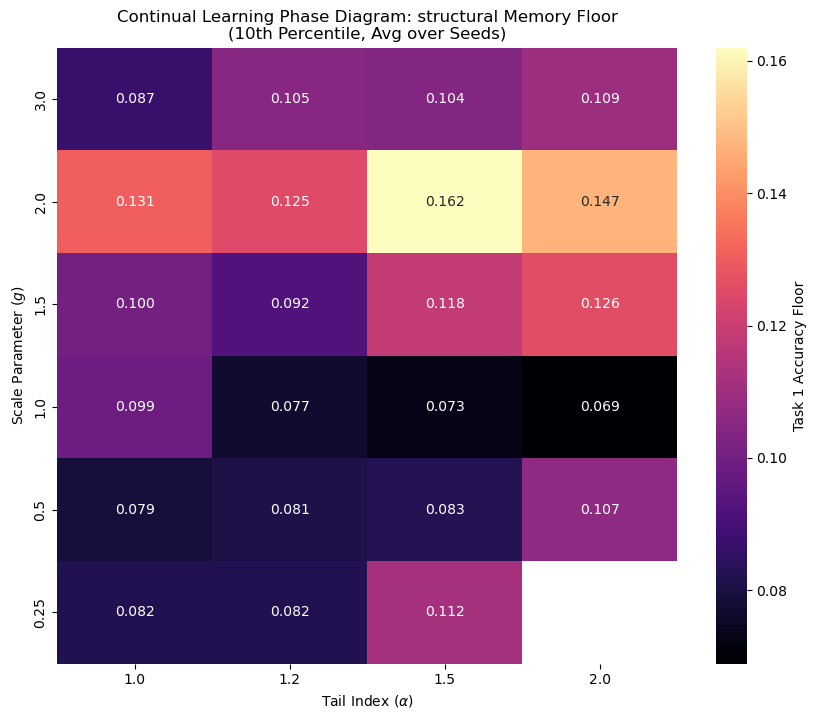

In [10]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fc10")
task_success_threshold = 0.93  # Run must hit this on Task 1 to be included
quantile_floor = 0.10          # 10th percentile floor

data_rows = []

# 1. Parse Directory Structure
for folder in results_path.iterdir():
    if not folder.is_dir() or "alpha" not in folder.name:
        continue

    # Extract alpha and g from folder name (alpha_X_g_Y)
    match = re.search(r"alpha_([\d.]+)_g_([\d.]+)", folder.name)
    if not match: continue
    alpha, g = float(match.group(1)), float(match.group(2))

    seed_floors = []

    # 2. Process each seed CSV in the subfolder
    for csv_file in folder.glob("results_log_seed_*.csv"):
        df = pd.DataFrame()
        try:
            df = pd.read_csv(csv_file)
        except Exception: continue

        # Trainability Filter: Ensure the model actually learned Task 1
        # Checks if Task 1 accuracy ever exceeded the threshold during Task 1 training
        if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
            continue

        # Calculate the 10th percentile floor from Task 2 to Task 10
        # This isolates the "forgotten" steady state from the training phase
        memory_data = df[df['task_id'] > 1]['task_1_acc']
        if not memory_data.empty:
            floor = memory_data.quantile(quantile_floor)
            seed_floors.append(floor)

    # 3. Average across successful seeds for this (alpha, g) pair
    if seed_floors:
        data_rows.append({
            'alpha': alpha,
            'g': g,
            'memory_floor': np.mean(seed_floors),
            'yield': len(seed_floors)  # Track how many seeds passed the filter
        })

# 4. Create Heatmap Data
master_df = pd.DataFrame(data_rows)
pivot_df = master_df.pivot(index="g", columns="alpha", values="memory_floor")
# Ensure axes are sorted correctly for the phase diagram
pivot_df = pivot_df.sort_index(ascending=False)

# 5. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="magma", cbar_kws={'label': 'Task 1 Accuracy Floor'})
plt.title(f"Continual Learning Phase Diagram: structural Memory Floor\n(10th Percentile, Avg over Seeds)")
plt.xlabel(r"Tail Index ($\alpha$)")
plt.ylabel(r"Scale Parameter ($g$)")
plt.show()

Processed 1 successful seeds for α=2.0, g=1.0
Processed 1 successful seeds for α=2.0, g=3.0
Processed 1 successful seeds for α=1.2, g=3.0


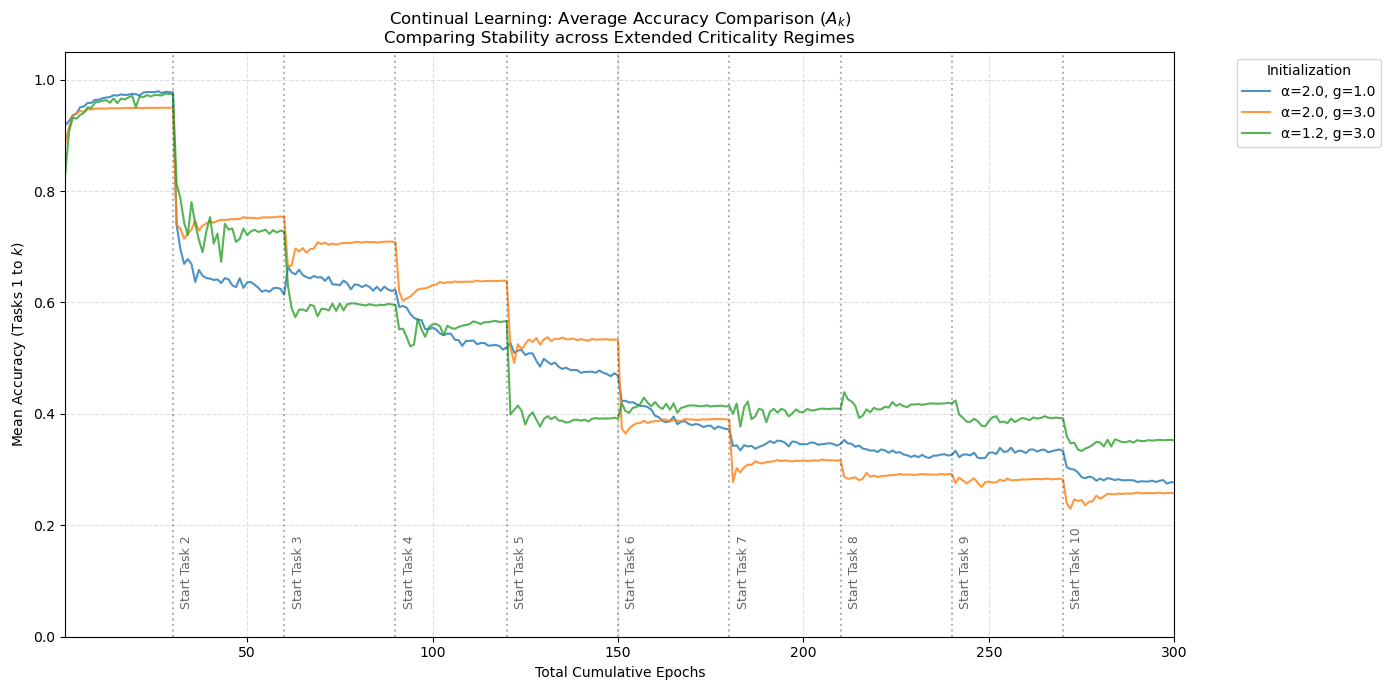

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fc10")
task_success_threshold = 0.93  # Filter out "dead" seeds
num_tasks = 10

def plot_multiple_accuracies(param_pairs):
    """
    param_pairs: List of tuples [(alpha, g), (alpha, g), ...]
    """
    master_plot_data = []
    task_transition_epochs = None

    for alpha, g in param_pairs:
        folder_name = f"alpha_{alpha}_g_{g}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        seed_count = 0
        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            df = pd.read_csv(csv_file)

            # Trainability Filter: Ensure model successfully learned Task 1
            if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
                continue

            seed_count += 1

            # Calculate Mean Accuracy (Ak) for every cumulative epoch
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                # Average only the tasks introduced so far
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_count
                })

            # Capture transition points from the first successful seed
            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} successful seeds for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    # Convert to DataFrame for Seaborn
    plot_df = pd.DataFrame(master_plot_data)

    # --- Plotting ---
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        errorbar="sd",
        alpha=0.8
    )

    # Vertical markers for Task transitions
    if task_transition_epochs:
        # Don't draw line for the final epoch
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
            plt.text(epoch_mark + 2, 0.05, f"Start Task {t_idx+2}",
                     fontsize=9, rotation=90, verticalalignment='bottom', alpha=0.6)

    plt.title("Continual Learning: Average Accuracy Comparison ($A_k$)\n"
              "Comparing Stability across Extended Criticality Regimes")
    plt.ylim(0, 1.05)
    plt.xlim(1, plot_df["Total Epoch"].max())
    plt.ylabel("Mean Accuracy (Tasks 1 to $k$)")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Initialization")
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Compare Gaussian Baseline vs various Heavy-Tailed setups[cite: 1]
comparison_list = [
    (2.0, 1.0),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (2.0, 3.0),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (1.2, 3.0),  # Standard Gaussian Edge-of-Chaos[cite: 1]
]

plot_multiple_accuracies(comparison_list)